In [2]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
X = data.drop(["List Price","IPO_Name","Date","Listing Gain","CMP(BSE)","CMP(NSE)","Current Gains"], axis=1)
y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)
model = DecisionTreeRegressor(random_state=42)

param_dist = {
    "max_depth": [None, 3, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8, 10]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
0.8974048968229947


In [4]:
best_d_model = random_search.best_estimator_
y_pred = best_d_model.predict(X_test)
print(y_pred[:10])

[ 11.26666667  50.          84.5         98.33333333 822.5
 107.8        263.81666667 630.05       662.         224.075     ]


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 68.45386768447837
RMSE: 112.8942146625915
R2: 0.9291068914002572


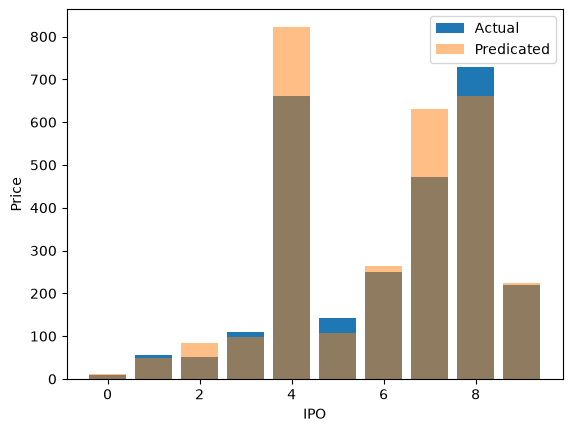

In [6]:
import matplotlib.pyplot as plt


plt.Figure(figsize=(10,6))
plt.bar(range(10) , y_test[:10]  ,label = "Actual")
plt.bar(range(10), y_pred[:10] ,alpha = 0.5 , label = "Predicated")

plt.xlabel("IPO")
plt.ylabel("Price")

plt.legend()
plt.show()

In [7]:
import joblib
joblib.dump(best_d_model, "Decision_Tree_Hyperparameter_Tuning.pkl")

['Decision_Tree_Hyperparameter_Tuning.pkl']